In [22]:
import env
import agent
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [ ]:

def check(state_Q_key):

    return jnp.logical_not(jnp.logical_or(state_Q_key[0] == 8, state_Q_key[0] == 4))






master_key = jax.random.key(0)
keys = jax.random.split(master_key, 100)

#metric counters
total_step_counts = 0

#tabQ must remain between runs
tabQ = jnp.zeros((9,4))


#needed for functions
epsilon = 0.1
gamma = 0.9
alpha = 0.5


def single_episode_gridworld(tabQ,key):

    state = 0
    state_Q = (state, tabQ, key)

    def b_func(state_Q_key):
        k1,k2 = jax.random.split(state_Q_key[2])
        policy = agent.epsilon_greedy(state_Q_key[0], state_Q_key[1], epsilon,k1)
        nstate,reward = env.gridworld(state_Q_key[0], policy)
        tabQ = agent.agent_updater(state_Q_key[0], policy, reward, nstate, state_Q_key[1], gamma, alpha)
        return (nstate, tabQ, k2)
    
    #runs a single episode. nstate = current state, tabQ is, Q estimates, k2 is split key
    state_Q  = jax.lax.while_loop(check, b_func, state_Q)

    #returns (nstate, tab)
    return (state_Q[1], state_Q[0])



(Array([[ -0.5,  -0.5,  -0.5,   0. ],
       [-50. ,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ],
       [ -0.5,  -0.5,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ],
       [ -0.5,  -0.5,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ]], dtype=float32), Array(4, dtype=int32))


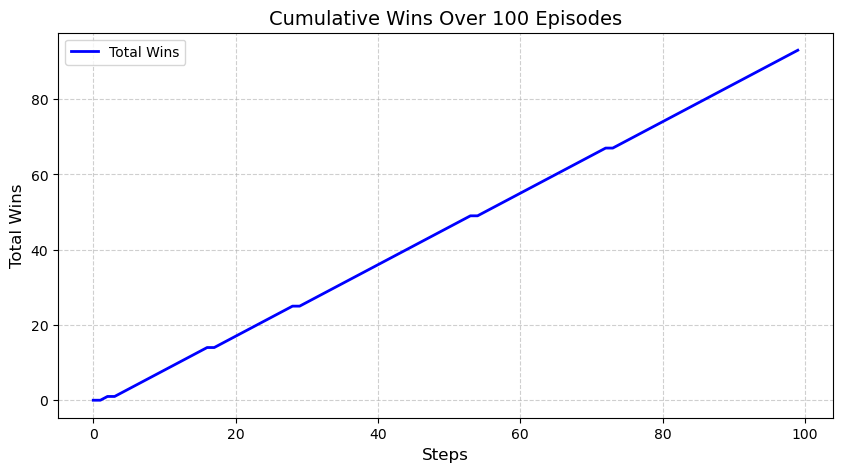

In [25]:
def multi_episode(tabQ, key):
    tab, current_state= jax.lax.scan(single_episode_gridworld, tabQ, key)
    return  tab, (current_state == 8)

final_tab, win_loss = multi_episode(tabQ, keys)

win_ints = win_loss.astype(jnp.int32)
cumalitive_wins = jnp.cumsum(win_ints)

plt.figure(figsize=(10,5))
plt.plot(cumalitive_wins, label = 'Total Wins', color = 'b', linewidth = 2)

plt.title('Cumulative Wins Over 100 Episodes', fontsize=14)
plt.xlabel('Steps', fontsize=12)
plt.ylabel('Total Wins', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()
